## PINN ME for 1.56 um BBSO/NIRIS 

### Train the model

In [7]:
# Add repository root to Python path
import sys
from pathlib import Path
import os

current_dir = Path(os.getcwd())
repo_root = current_dir.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'Repository root: {repo_root}')

Repository root: /mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository


## Setup

First, we need to add the repository root to Python's path so we can import the `src` module. This cell detects the repository root and adds it to `sys.path`.

In [24]:
from pathlib import Path
import glob
from src import process_ME_inversion_pinn
import os
import torch
from src import MEInversionPINN
from src import prepare_stokes_data
from src import infer_with_pinn
from src.visualization import visualize_Bx_By_Bz
from astropy.io import fits
from matplotlib import pyplot as plt
import numpy as np
# Set file paths
research_dir = Path('/research/bs644/ql47/NIRIS')
file_name =  '20240725_cals_recalibrated'
data_folder = research_dir / file_name
workdir = Path(repo_root / 'tests' / file_name)
workdir.mkdir(exist_ok=True, parents=True)
output_dir = workdir / 'results'
output_dir.mkdir(exist_ok=True, parents=True)
infer_dir = workdir / 'infer'
infer_dir.mkdir(exist_ok=True, parents=True)
models_dir = repo_root / 'models'
print(f'data_folder: {data_folder}')
print(f'output_dir: {output_dir}')
print(f'infer_dir: {infer_dir}')
print(f'Models directory: {models_dir}')


data_folder: /research/bs644/ql47/NIRIS/20240725_cals_recalibrated
output_dir: /mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/tests/20240725_cals_recalibrated/results
infer_dir: /mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/tests/20240725_cals_recalibrated/infer
Models directory: /mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/models


## Training a New Model

This cell trains a new PINN model on the specified data file. The function `process_ME_inversion_pinn` will:
- Load the Stokes profiles from the data folder
- Train a new model (if `model_path` is not provided)
- Perform inference on the data
- Save the results to the output directory

**Parameters:**
- `n_epochs`: Number of training epochs
- `batch_size`: Batch size for training
- `inference_batch_size`: Batch size for inference
- `sample_index`: Which file in the folder to use for training purpose
- `dropout_rate`: Dropout regularization (0 = disabled)
- `weight_decay`: L2 regularization factor

In [41]:
# Train the model
results = process_ME_inversion_pinn(
    data_folder, 
    output_dir=output_dir,
    n_epochs=100,                
    batch_size=256,            
    inference_batch_size=256,
    validation_split=0.2,
    activation='tanh',
    optimizer_type='adam',
    sample_index=2,              # Use the 2nd file
    dropout_rate=0,          
    weight_decay=1e-5      
)

Using device: cuda
Selected file for training: /research/bs644/ql47/NIRIS/20240725_cals_recalibrated/cals_240725_163324.fts


/mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/src/Training.py:511: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wavelengths_tensor = torch.tensor(wavelengths, dtype=torch.float32).to(device)


Training new model with tanh activation using adam optimizer
Loading data file: /research/bs644/ql47/NIRIS/20240725_cals_recalibrated/cals_240725_163324.fts
Training on 414720 samples, validating on 103680 samples


Training Progress:   0%|          | 0/100 [00:00<?, ?it/s]/mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/src/Training.py:578: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dtype=torch.float32).to(device)
/mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/src/Training.py:581: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dtype=torch.float32).to(device)
Training Progress:   0%|          | 0/100 [01:03<?, ?it/s, Epoch=1/100, Batch=1620/1620, Batch Loss=0.211363]/mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/src/Training.py:629: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach()

KeyboardInterrupt: 

## Loading a Pre-trained Model

Alternatively, you can load a pre-trained model instead of training a new one. This is useful if you've already trained a model and want to use it for inference on new data.

In [ ]:
# Load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_path = glob.glob(str(models_dir / 'trained' / 'me_pinn_model_*.pt'))[0]
# Set the data file
data_files = data_folder.glob('*.fts')
data_file = list(data_files)[20]
print(data_file)
# Prepare data for model size determination
data, wavelengths, _ = prepare_stokes_data(data_file)
_, _, nw, _ = data.shape

# Load or train model
print(f"Loading model from {model_path}")
model = MEInversionPINN(nw).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))


Using device: cuda
/research/bs644/ql47/NIRIS/20240725_cals_recalibrated/cals_240725_165151.fts
Loading model from /mmfs1/project/bs644/ql47/ME/PINN4ME/scr/github_repository/models/trained/me_pinn_model_cals_240725_163222_adam.pt


<All keys matched successfully>

## Inspecting Input Data

Let's visualize one of the Stokes profiles (Q component) to verify the data is loaded correctly.

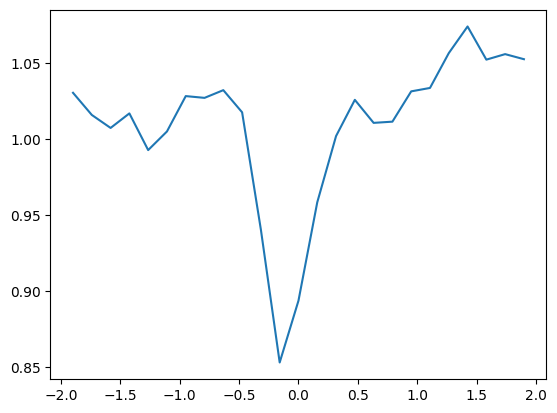

In [40]:
# Check the input data, here Stokes Q
observational_profile = data.cpu().numpy()
profile_I = observational_profile[600,300,:,0]
profile_Q = observational_profile[600,300,:,1]
profile_U = observational_profile[600,300,:,2]
profile_V = observational_profile[600,300,:,3]

plt.plot(wavelengths, profile_I)
plt.show()


## Running Inference

Perform ME inversion on the data file using the pretrained model. This will predict ME parameters for one image and generate fitted Stokes profiles.

In [36]:
parameters_map, stokes_fitted = infer_with_pinn(
        model,
        data_file,
        output_dir=output_dir,
        batch_size=512
    )
results = {
        'parameters': parameters_map,
        'stokes_fitted': stokes_fitted,
        'wavelengths': wavelengths
    }

100%|██████████| 1013/1013 [00:20<00:00, 50.20it/s]


## Visualizing Results

Compare the fitted Stokes profiles from ME-PINN with the observed data at a specific pixel location. The plot shows all four Stokes components (I, Q, U, V) and displays the inferred ME parameters.

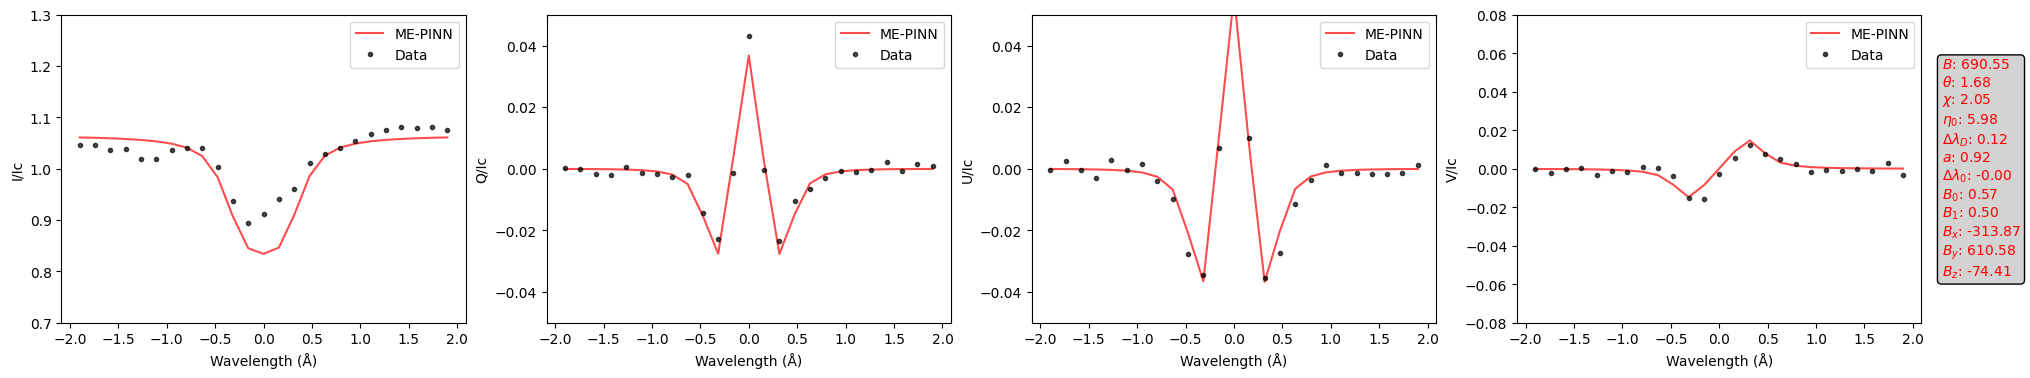

In [ ]:
parameters_map_PINN = results['parameters']
stokes_fitted_PINN = results['stokes_fitted']
wavelengths_PINN = results['wavelengths']

observational_profile_I = data.cpu().numpy()

xspatial,yspatial = 450, 350
fig, axs = plt.subplots(1, 4, figsize=(24, 4))
axs[0].plot(wavelengths_PINN, stokes_fitted_PINN[xspatial,yspatial,:,0], 'r-', label='MVPinn', alpha=0.7)
axs[0].plot(wavelengths_PINN, observational_profile_I[xspatial,yspatial,:,0], 'k.', label='Data', alpha=0.7)
axs[0].legend()
axs[0].set_ylim(0.7,1.3)
axs[0].set_xlabel('Wavelength (Å)')
axs[0].set_ylabel('I/Ic')

axs[1].plot(wavelengths_PINN, stokes_fitted_PINN[xspatial,yspatial,:,1], 'r-', label='MVPinn', alpha=0.7)
axs[1].plot(wavelengths_PINN, observational_profile_I[xspatial,yspatial,:,1], 'k.', label='Data', alpha=0.7)
axs[1].legend()
axs[1].set_ylim(-0.05,0.05)
axs[1].set_xlabel('Wavelength (Å)')
axs[1].set_ylabel('Q/Ic')

axs[2].plot(wavelengths_PINN, stokes_fitted_PINN[xspatial,yspatial,:,2], 'r-', label='MVPinn', alpha=0.7)
axs[2].plot(wavelengths_PINN, observational_profile_I[xspatial,yspatial,:,2], 'k.', label='Data', alpha=0.7)
axs[2].legend()
axs[2].set_ylim(-0.05,0.05)
axs[2].set_xlabel('Wavelength (Å)')
axs[2].set_ylabel('U/Ic')

axs[3].plot(wavelengths_PINN, stokes_fitted_PINN[xspatial,yspatial,:,3], 'r-', label='MVPinn', alpha=0.7)
axs[3].plot(wavelengths_PINN, observational_profile_I[xspatial,yspatial,:,3], 'k.', label='Data', alpha=0.7)
axs[3].legend()
axs[3].set_ylim(-0.08,0.08)
axs[3].set_xlabel('Wavelength (Å)')
axs[3].set_ylabel('V/Ic')

# Add parameters to the plot
text_params_PINN = parameters_map_PINN[xspatial,yspatial,:]
Bx = text_params_PINN[0] * np.sin(text_params_PINN[1]) * np.cos(text_params_PINN[2])
By = text_params_PINN[0] * np.sin(text_params_PINN[1]) * np.sin(text_params_PINN[2])
Bz = text_params_PINN[0] * np.cos(text_params_PINN[1])
text_params_PINN = np.concatenate((text_params_PINN, Bx[np.newaxis], By[np.newaxis], Bz[np.newaxis]), axis=0)
params = ['$B$', '$\\theta$', '$\\chi$', '$\\eta_0$', '$\\Delta\\lambda_D$', '$a$', '$\\Delta\\lambda_0$', '$B_0$', '$B_1$', '$B_x$', '$B_y$', '$B_z$']
params_text_PINN = '\n'.join([f'{params[i]}: {value:.2f}' for i, value in enumerate(text_params_PINN)])
axs[3].text(1.05, 0.5, params_text_PINN, transform=axs[3].transAxes, fontsize=10, verticalalignment='center', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='lightgrey'), color='red')

plt.savefig(output_dir / 'stokes_fitted_3.jpg',dpi=300,bbox_inches='tight')
plt.show()

## Saving Results

Visualize and save the magnetic field components (Bx, By, Bz) as FITS files.

dict_keys(['parameters', 'stokes_fitted', 'wavelengths'])


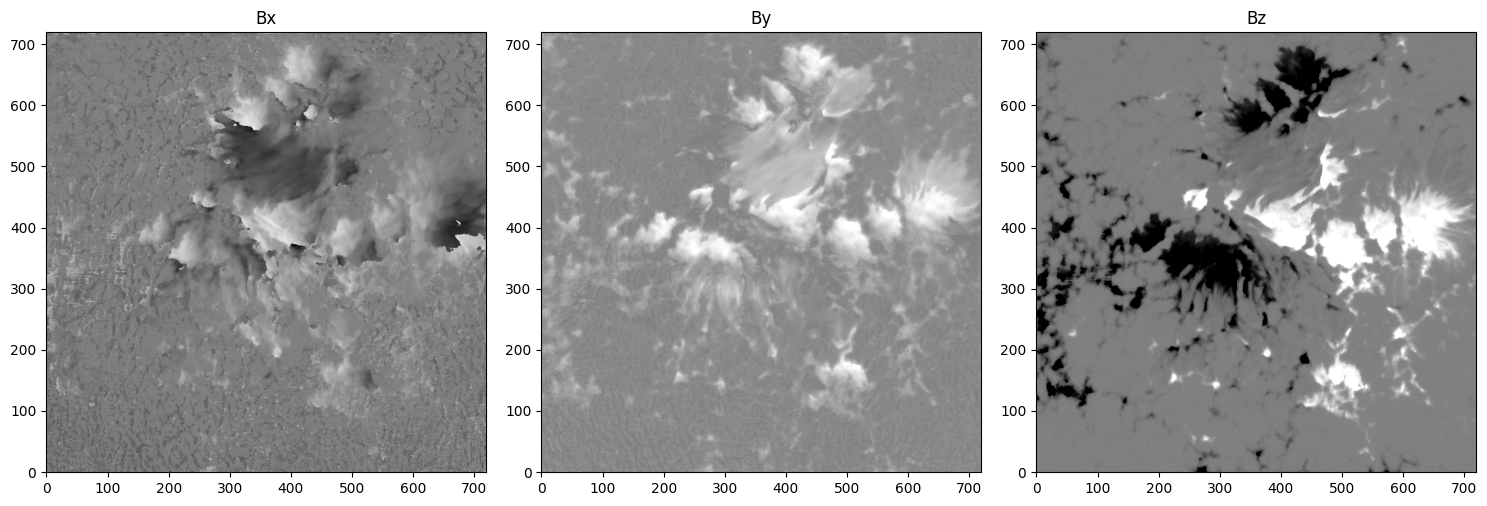

In [39]:
Bx, By, Bz = visualize_Bx_By_Bz(results, output_dir)

fits.writeto(output_dir / 'PINN_Bx.fits', Bx, overwrite=True)
fits.writeto(output_dir / 'PINN_By.fits', By, overwrite=True)
fits.writeto(output_dir / 'PINN_Bz.fits', Bz, overwrite=True)